# BIM 430 - Derin Öğrenme Projesi
## Model 3: Bidirectional LSTM (BiLSTM) - Literatür Mimarisi

**Veri Seti:** IMDB Film Yorumları (Model 1 ve Model 2 ile AYNI)

**Mimari:** Embedding → Bidirectional LSTM → Dense → Dropout → Sigmoid

**Önemli Notlar:**
- BiLSTM mimarisi Schuster & Paliwal (1997) tarafından önerilmiştir.
- Model **sıfırdan eğitilmektedir**, pretrained ağırlık kullanılmamıştır.
- Transfer learning YOK, fine-tuning YOK.
- Veri pipeline'ı ve hiperparametreler Model 1 ve Model 2 ile birebir aynıdır.

## 1. Kütüphaneler ve Ayarlar

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import random
import os
import json

# Tekrarlanabilirlik için seed sabitleme (Model 1 ve Model 2 ile AYNI!)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU kontrolü
print("TensorFlow versiyonu:", tf.__version__)
print("GPU kullanılabilir:", tf.config.list_physical_devices('GPU'))

TensorFlow versiyonu: 2.19.0
GPU kullanılabilir: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Google Drive Bağlantısı

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/deeplearning/model3'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Kayıt klasörü: {SAVE_PATH}")

Mounted at /content/drive
Kayıt klasörü: /content/drive/MyDrive/deeplearning/model3


## 3. Veri Yükleme ve Ön İşleme (Model 1 ve 2 ile BİREBİR AYNI)

⚠️ Adil karşılaştırma için tüm hiperparametreler aynı.

In [3]:
# Hiperparametreler (Model 1 ve 2 ile AYNI)
VOCAB_SIZE = 10000
MAX_LEN = 250
EMBED_DIM = 128
BATCH_SIZE = 64
EPOCHS = 15

# Veriyi yükle
(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Eğitim örnek sayısı: {len(x_train_full)}")
print(f"Test örnek sayısı: {len(x_test)}")
print(f"Sınıf dağılımı (eğitim): {np.bincount(y_train_full)}")
print(f"Sınıf dağılımı (test): {np.bincount(y_test)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim örnek sayısı: 25000
Test örnek sayısı: 25000
Sınıf dağılımı (eğitim): [12500 12500]
Sınıf dağılımı (test): [12500 12500]


In [4]:
# Padding
x_train_full = pad_sequences(x_train_full, maxlen=MAX_LEN, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

# Validation split (deterministik - seed sabit)
val_size = 2500
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print(f"Eğitim: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")
print(f"Train sınıf dağılımı: {np.bincount(y_train)}")
print(f"Val sınıf dağılımı: {np.bincount(y_val)}")

Eğitim: (22500, 250), Validation: (2500, 250), Test: (25000, 250)
Train sınıf dağılımı: [11282 11218]
Val sınıf dağılımı: [1218 1282]


## 4. Model 3: Bidirectional LSTM (BiLSTM)

### Mimari Kararları

BiLSTM, standart LSTM'in iki yönlü versiyonudur:
- **İleri LSTM:** Metni baştan sona okur (soldan sağa)
- **Geri LSTM:** Metni sondan başa okur (sağdan sola)
- **Birleştirme:** İki yönün çıktıları concatenate edilir

### Model 2 (Tek Yönlü LSTM) ile Farkı

| Özellik | Model 2 (LSTM) | Model 3 (BiLSTM) |
|---------|---------------|------------------|
| Okuma yönü | Tek yönlü (→) | Çift yönlü (↔) |
| Parametre sayısı | Normal | ~2x (iki LSTM) |
| Bağlam | Sadece geçmiş | Geçmiş + gelecek |
| 'not good' gibi ifadeler | Zayıf | Güçlü |
| Eğitim süresi | Normal | ~2x daha yavaş |

### Neden Metin Sınıflandırmada Önemli?

"The movie was **not** as good as I **hoped**." cümlesinde:
- Tek yönlü LSTM 'not' kelimesini gördüğünde 'good'un ne olacağını bilmiyor
- BiLSTM 'good' kelimesini işlerken hem öncesinde 'not' olduğunu hem sonrasında 'hoped' olduğunu biliyor
- Bu sayede olumsuzlama ve bağlamsal nüansları daha iyi yakalar

### Kaynak
Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on Signal Processing*, 45(11), 2673-2681.

In [5]:
def build_bilstm_model():
    """Literatür BiLSTM mimarisi - sıfırdan eğitim"""
    inputs = keras.Input(shape=(MAX_LEN,), name='input_tokens')

    # Embedding - sıfırdan eğitilir
    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        name='embedding'
    )(inputs)

    # Bidirectional LSTM
    x = layers.Bidirectional(
        layers.LSTM(
            units=64,  # Toplam çıkış: 64*2 = 128 (Model 2 ile aynı toplam boyut)
            dropout=0.2,
            recurrent_dropout=0.0,
        ),
        name='bilstm'
    )(x)

    # Regularization ve dense katmanlar
    x = layers.Dropout(0.5, name='dropout_1')(x)
    x = layers.Dense(32, activation='relu', name='dense_hidden')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # Çıkış
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs, outputs, name='BiLSTM_Literature')
    return model

model_3 = build_bilstm_model()
model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_Literature"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,382,977 (5.28 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Model mimarisini görselleştir
keras.utils.plot_model(
    model_3,
    to_file=f'{SAVE_PATH}/model3_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)
print(f"Mimari görseli kaydedildi: {SAVE_PATH}/model3_architecture.png")

Mimari görseli kaydedildi: /content/drive/MyDrive/deeplearning/model3/model3_architecture.png


## 5. Model Eğitimi

⏱️ **Dikkat:** BiLSTM iki yönlü olduğu için tek yönlü LSTM'den yaklaşık 2x yavaştır. T4'te toplam eğitim ~15-20 dakika sürebilir.

In [7]:
# Derleme (Model 1 ve 2 ile AYNI)
model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback'ler (Model 1 ve 2 ile AYNI)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Eğitim
history_3 = model_3.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6998 - loss: 0.5753 - val_accuracy: 0.7960 - val_loss: 0.4502
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8503 - loss: 0.3719 - val_accuracy: 0.8656 - val_loss: 0.3305
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9002 - loss: 0.2689 - val_accuracy: 0.8512 - val_loss: 0.4145
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9107 - loss: 0.2487 - val_accuracy: 0.8476 - val_loss: 0.3616
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9307 - loss: 0.1967 - val_accuracy: 0.8612 - val_loss: 0.4103
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## 6. Eğitim Grafikleri (Loss ve Accuracy)

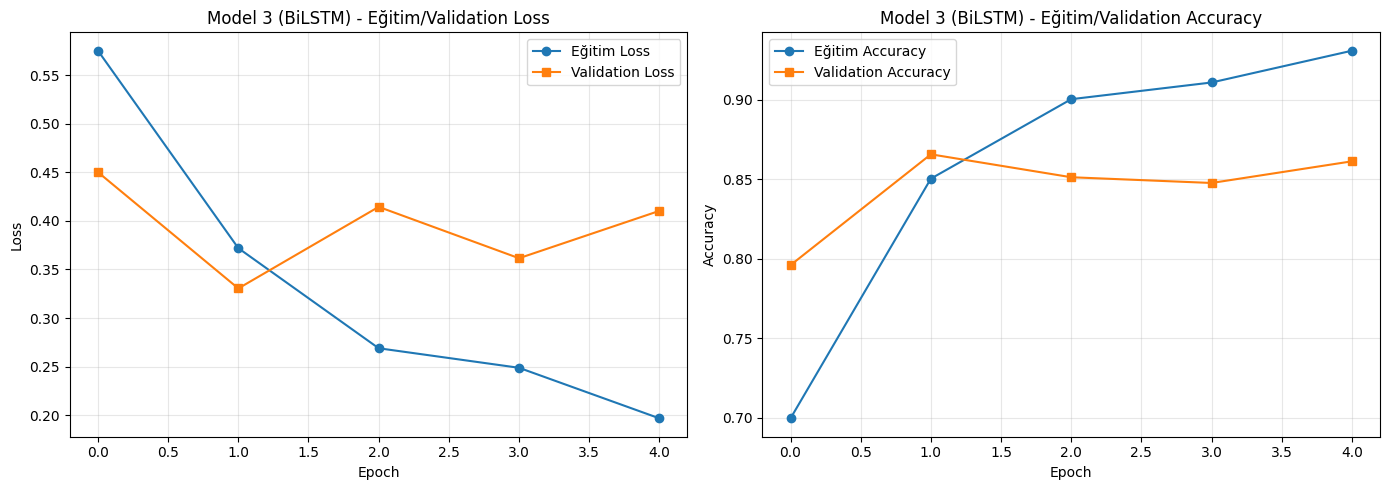

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
axes[0].plot(history_3.history['loss'], label='Eğitim Loss', marker='o')
axes[0].plot(history_3.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model 3 (BiLSTM) - Eğitim/Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(history_3.history['accuracy'], label='Eğitim Accuracy', marker='o')
axes[1].plot(history_3.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model 3 (BiLSTM) - Eğitim/Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/model3_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Test Seti Değerlendirme ve Metrikler

In [9]:
# Test seti üzerinde tahmin
y_pred_proba = model_3.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrikler
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL 3 - BiLSTM - Test Sonuçları")
print("=" * 50)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Pozitif']))

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
MODEL 3 - BiLSTM - Test Sonuçları
Accuracy : 0.8484
Precision: 0.8434
Recall   : 0.8558
F1-Score : 0.8495

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Negatif       0.85      0.84      0.85     12500
     Pozitif       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



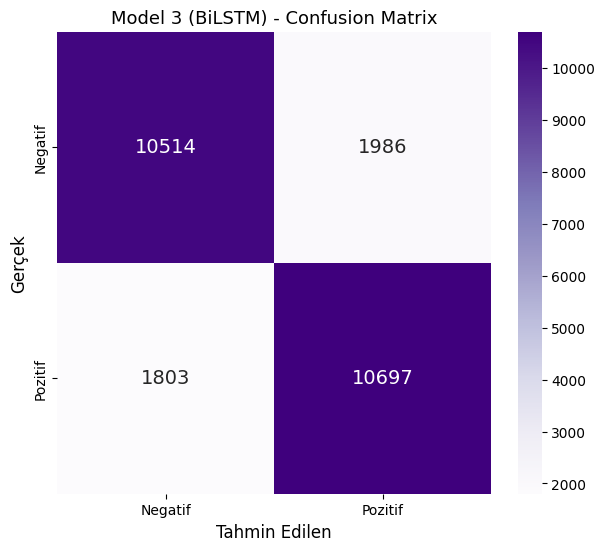

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'],
            cbar=True, annot_kws={'size': 14})
plt.xlabel('Tahmin Edilen', fontsize=12)
plt.ylabel('Gerçek', fontsize=12)
plt.title('Model 3 (BiLSTM) - Confusion Matrix', fontsize=13)
plt.savefig(f'{SAVE_PATH}/model3_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Sonuçları Drive'a Kaydet

In [11]:
# Metrikleri JSON olarak kaydet
results_model_3 = {
    'model_name': 'Bidirectional LSTM (Literature)',
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'history': {k: [float(v) for v in vals] for k, vals in history_3.history.items()},
    'hyperparameters': {
        'vocab_size': VOCAB_SIZE,
        'max_len': MAX_LEN,
        'embed_dim': EMBED_DIM,
        'bilstm_units': 64,
        'bilstm_output_dim': 128,
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'seed': SEED
    }
}

# JSON
json_path = f'{SAVE_PATH}/results_model_3.json'
with open(json_path, 'w') as f:
    json.dump(results_model_3, f, indent=2)
print(f"✅ JSON kaydedildi: {json_path}")

# Model
model_path = f'{SAVE_PATH}/model_3_bilstm.keras'
model_3.save(model_path)
print(f"✅ Model kaydedildi: {model_path}")

# Tüm dosyaları listele
print("\n" + "="*60)
print("MODEL 3 - TÜM DOSYALAR")
print("="*60)
for f in sorted(os.listdir(SAVE_PATH)):
    filepath = f'{SAVE_PATH}/{f}'
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  📄 {f} ({size_kb:.1f} KB)")

✅ JSON kaydedildi: /content/drive/MyDrive/deeplearning/model3/results_model_3.json
✅ Model kaydedildi: /content/drive/MyDrive/deeplearning/model3/model_3_bilstm.keras

MODEL 3 - TÜM DOSYALAR
  📄 model3_architecture.png (53.6 KB)
  📄 model3_bilstm.ipynb (30.0 KB)
  📄 model3_confusion_matrix.png (30.2 KB)
  📄 model3_training_curves.png (70.5 KB)
  📄 model_3_bilstm.keras (16256.7 KB)
  📄 results_model_3.json (1.1 KB)


## 9. README.md Oluştur

In [12]:
readme_content = f"""# Model 3: Bidirectional LSTM (Literatür Mimarisi)

**BIM 430 — Derin Öğrenme Projesi**

---

## 📌 Proje Özeti

Bu klasör, IMDB film yorumları üzerinde duygu analizi yapan projenin **üçüncü modelini** içerir. Model literatürde yaygın kullanılan **Bidirectional LSTM (BiLSTM)** mimarisidir ve sıfırdan eğitilmiştir.

BiLSTM, metni hem ileri (soldan sağa) hem de geri (sağdan sola) yönlerde işleyerek, her kelime için hem geçmiş hem de gelecek bağlamı dikkate alır.

---

## 📊 Veri Seti

Model 1 ve Model 2 ile **birebir aynı** veri seti ve ön işleme kullanılmıştır:
- Keras IMDB Dataset
- 22.500 eğitim / 2.500 validation / 25.000 test
- VOCAB_SIZE = 10.000, MAX_LEN = 250
- SEED = 42 (deterministik bölünme)

---

## 🧠 Model Mimarisi

```
Input (250 token)
    ↓
Embedding (10000 → 128 boyut, sıfırdan)
    ↓
Bidirectional LSTM (64 birim × 2 yön = 128 boyut)
    ↓
Dropout (0.5)
    ↓
Dense (32, ReLU)
    ↓
Dropout (0.3)
    ↓
Dense (1, Sigmoid)
```

### Literatür Kaynağı
Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on Signal Processing*, 45(11), 2673-2681.

---

## ⚙️ Eğitim Yapılandırması

Model 1 ve Model 2 ile birebir aynı hiperparametreler:
- Optimizer: Adam (lr=0.001)
- Loss: Binary Crossentropy
- Batch Size: 64
- Max Epochs: 15
- Early Stopping: patience=3
- Seed: 42

---

## 📈 Sonuçlar

| Metrik | Değer |
|--------|-------|
| **Accuracy** | {acc:.4f} |
| **Precision** | {prec:.4f} |
| **Recall** | {rec:.4f} |
| **F1-Score** | {f1:.4f} |

---

## 📁 Dosyalar

- `model3_bilstm.ipynb` — Ana notebook
- `model_3_bilstm.keras` — Eğitilmiş model
- `results_model_3.json` — Metrikler ve history
- `model3_training_curves.png` — Loss/Accuracy grafikleri
- `model3_confusion_matrix.png` — Confusion matrix
- `model3_architecture.png` — Mimari görseli

---

## ⚠️ Önemli

- Transfer learning KULLANILMAMIŞTIR.
- Fine-tuning YAPILMAMIŞTIR.
- Embedding dahil tüm ağırlıklar sıfırdan öğrenilmiştir.
- Model 1, Model 2 ve Model 3 aynı veri kümesi ve aynı hiperparametrelerle eğitilmiştir.
"""

readme_path = f'{SAVE_PATH}/README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f"✅ README.md kaydedildi: {readme_path}")

✅ README.md kaydedildi: /content/drive/MyDrive/deeplearning/model3/README.md


## 10. Sonuç Yorumu

(Kendi gözlemlerinle doldur)

- BiLSTM kaç epoch'ta early stopping ile durdu?
- Tek yönlü LSTM'e göre nasıl bir performans artışı var?
- İki yönlü işlemenin faydası görülüyor mu?
- CNN ile kıyaslandığında hangisi kazandı?

### Sonraki Adım
Üç modelin de sonuçları alındı. Sırada **karşılaştırma ve analiz** aşaması var.